### <span style="color:purple; font-size:1.5em; font-weight:bold;">Market Basket Analysis using ECLAT, Apriori, and FP-Growth</span>


**Task I am doing:** I am applying Apriori and ECLAT on `Groceries_dataset.csv`, then performing a comparative analysis of Apriori, ECLAT, and FP-Growth based on frequent itemsets, association rules, execution time, and memory usage.


In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
groceries_data = pd.read_csv("dataset/Groceries_dataset.csv")


In [2]:
duplicates = groceries_data['Member_number'].duplicated().any()
print("Is there a repeated Member_number? ", duplicates)


Is there a repeated Member_number?  True


#Convert the dataset into a list of transactions

In [3]:
transactions = groceries_data.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).tolist()


#Show the first 10 transactions

In [4]:
for i, transaction in enumerate(transactions[:10]):
    print(f"Transaction {i+1}: {transaction}")


Transaction 1: ['sausage', 'whole milk', 'semi-finished bread', 'yogurt']
Transaction 2: ['whole milk', 'pastry', 'salty snack']
Transaction 3: ['canned beer', 'misc. beverages']
Transaction 4: ['sausage', 'hygiene articles']
Transaction 5: ['soda', 'pickled vegetables']
Transaction 6: ['frankfurter', 'curd']
Transaction 7: ['sausage', 'whole milk', 'rolls/buns']
Transaction 8: ['whole milk', 'soda']
Transaction 9: ['beef', 'white bread']
Transaction 10: ['frankfurter', 'soda', 'whipped/sour cream']


#**ECLAT** was applied to only the first 2000 transactions due to its higher computational cost and slower performance on larger datasets.


In [5]:

# Select only the first 5000 transactions
transactions = transactions[:2000]

In [6]:

# Convert transactions list into a DataFrame (required by pyECLAT)
df_transactions = pd.DataFrame(transactions)

# ECLAT Algorithm


In [ ]:
from pyECLAT import ECLAT
# Create ECLAT model
my_eclat = ECLAT(data=df_transactions, verbose=True)

# Define parameters
min_n_products = 1 # Minimum number of items in a set
min_support = 0.01# Support threshold
max_length = 2 # Limit max itemset size

# Fit ECLAT
rule_indices, rule_supports = my_eclat.fit(
    min_support=min_support, min_combination=min_n_products, max_combination=max_length
)

# Display results
print("Frequent Itemsets:", rule_indices)
print("Support Values:", rule_supports)

  0%|          | 0/157 [00:00<?, ?it/s]

100%|██████████| 157/157 [00:00<00:00, 11398.55it/s]


Combination 1 by 1


70it [00:01, 41.01it/s]


Combination 2 by 2


428it [00:05, 84.30it/s]

# Apriori Algorithm

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder


# Load dataset
groceries_data = pd.read_csv("dataset/Groceries_dataset.csv")

# Convert dataset into list of transactions1
transactions1 = groceries_data.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).tolist()


# Convert transactions1 list into a DataFrame (required by pyECLAT)
df_transactions = pd.DataFrame(transactions1)


In [ ]:
# Encode transactions using TransactionEncoder
encoder = TransactionEncoder()
encoded_array = encoder.fit(transactions1).transform(transactions1)


In [ ]:
# Convert to DataFrame
df_encoded = pd.DataFrame(encoded_array, columns=encoder.columns_)

In [ ]:
df_encoded.shape

(14963, 168)

In [ ]:
# Define min_support (same as ECLAT)
min_support = 7 / len(transactions1)

# Apply Apriori algorithm
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

# Extract association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Display results
print("Frequent Itemsets:\n", frequent_itemsets)
print("\nAssociation Rules:\n", rules)

Frequent Itemsets:
        support                              itemsets
0     0.004010               (Instant food products)
1     0.021386                            (UHT-milk)
2     0.001470                    (abrasive cleaner)
3     0.001938                    (artif. sweetener)
4     0.008087                       (baking powder)
...        ...                                   ...
1673  0.000601     (soda, whole milk, shopping bags)
1674  0.000535   (whole milk, yogurt, shopping bags)
1675  0.000668    (soda, whole milk, tropical fruit)
1676  0.000936            (soda, whole milk, yogurt)
1677  0.000802  (whole milk, yogurt, tropical fruit)

[1678 rows x 2 columns]

Association Rules:
                        antecedents                   consequents  \
0                       (UHT-milk)                 (butter milk)   
1                    (butter milk)                    (UHT-milk)   
2                       (UHT-milk)                     (chicken)   
3                        (

In [ ]:
# Display top 10 association rules
print("\n🔹 **Top 10 Association Rules:**\n")
print(rules.nlargest(10, 'lift')[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_string(index=False))


🔹 **Top 10 Association Rules:**

                     antecedents                      consequents  support  confidence     lift
            (pickled vegetables)                            (ham) 0.000535    0.059701 3.489506
                           (ham)             (pickled vegetables) 0.000535    0.031250 3.489506
                  (curd, yogurt)                        (sausage) 0.000468    0.205882 3.411537
                       (sausage)                   (curd, yogurt) 0.000468    0.007752 3.411537
(whipped/sour cream, whole milk)                           (beef) 0.000468    0.101449 2.988160
                          (beef) (whipped/sour cream, whole milk) 0.000468    0.013780 2.988160
                         (herbs)                            (oil) 0.000468    0.044304 2.972725
                           (oil)                          (herbs) 0.000468    0.031390 2.972725
            (pork, citrus fruit)               (other vegetables) 0.000468    0.350000 2.866475
      

# FP (Frequent Pattern) Growth Algorithm

In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
# Transform data using TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions1).transform(transactions1)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Define min_support (same as before)
min_support = 7 / len(transactions1)  

# Generate frequent itemsets using FP-Growth
frequent_itemsets = fpgrowth(df_encoded, min_support=min_support, use_colnames=True)

# Display frequent itemsets
print("Frequent Itemsets:")
print(frequent_itemsets)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)

# Display association rules
print("\nAssociation Rules:")
print(rules)

Frequent Itemsets:
       support                            itemsets
0     0.157923                        (whole milk)
1     0.085879                            (yogurt)
2     0.060349                           (sausage)
3     0.009490               (semi-finished bread)
4     0.051728                            (pastry)
...        ...                                 ...
1673  0.000468     (frozen dessert, bottled water)
1674  0.000468  (other vegetables, frozen dessert)
1675  0.000468            (frozen dessert, yogurt)
1676  0.000601              (frozen dessert, soda)
1677  0.000468       (frozen dessert, canned beer)

[1678 rows x 2 columns]

Association Rules:
                    antecedents         consequents  antecedent support  \
0                      (yogurt)        (whole milk)            0.085879   
1                (soda, yogurt)        (whole milk)            0.005814   
2    (other vegetables, yogurt)        (whole milk)            0.008087   
3          (whole milk, 

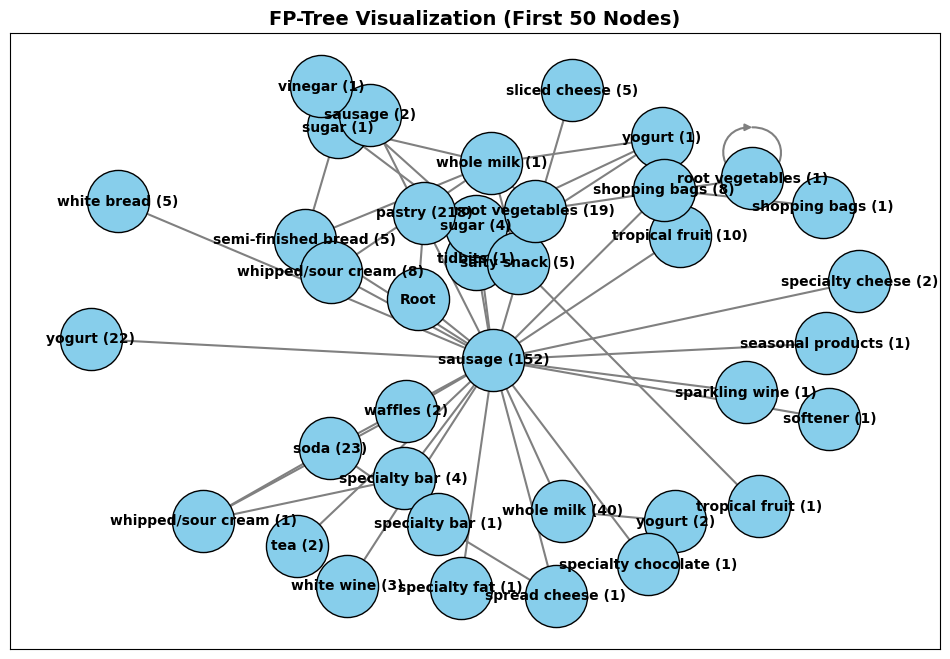

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

class FPTree:
    def __init__(self):
        self.tree = defaultdict(lambda: defaultdict(dict))  # Nested dictionary for tree structure
        self.node_count = 0  # Keep track of the number of nodes

    def add_transaction(self, transaction):
        current_node = self.tree
        for item in transaction:
            if item not in current_node:
                current_node[item] = {"_count": 0}  # Initialize with a dictionary
            
            current_node[item]["_count"] += 1  # Increment count
            current_node = current_node[item]  # Move to next level

    def visualize_tree(self, max_nodes=50):
        G = nx.DiGraph()  # Directed graph
        self.node_count = 0  # Reset count

        def add_edges(node, parent="Root"):
            if self.node_count >= max_nodes:
                return  # Stop adding nodes when limit is reached

            for key, value in node.items():
                if key != "_count" and self.node_count < max_nodes:
                    node_name = f"{key} ({value['_count']})"
                    G.add_node(node_name)
                    G.add_edge(parent, node_name)
                    self.node_count += 1
                    add_edges(value, node_name)  # Recursive call to add deeper nodes

        add_edges(self.tree)

        # Set up a better hierarchical layout
        plt.figure(figsize=(12, 8))  # Increase figure size
        pos = nx.spring_layout(G, seed=42, k=0.5)  # Use a layout that prevents overlap

        # Draw nodes
        nx.draw_networkx_nodes(G, pos, node_color="skyblue", node_size=2000, edgecolors="black")

        # Draw edges
        nx.draw_networkx_edges(G, pos, edge_color="gray", width=1.5)

        # Draw labels
        nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

        plt.title("FP-Tree Visualization (First 50 Nodes)", fontsize=14, fontweight="bold")
        plt.show()

# Create FP-Tree
fp_tree = FPTree()
for transaction in transactions1:
    fp_tree.add_transaction(sorted(transaction))  # Sorting to maintain FP-Growth order

# Visualize the FP-Tree (only first 50 nodes)
fp_tree.visualize_tree(max_nodes=50)


# Performing comparative analysis among ECLAT , APRIORI and FP Growth Algoritm

In [ ]:
import time
from memory_profiler import memory_usage
import pandas as pd


# Creating a benchmark function

In [ ]:
def benchmark_algorithm(func, *args, **kwargs):
    start_time = time.time()
    mem_usage = memory_usage((func, args, kwargs), max_iterations=1)
    end_time = time.time()

    return {
        "Execution Time (s)": round(end_time - start_time, 4),
        "Memory Usage (MB)": round(max(mem_usage), 4),
    }


In [ ]:
def run_apriori():
    encoder = TransactionEncoder()
    encoded_array = encoder.fit(transactions1).transform(transactions1)
    df_encoded = pd.DataFrame(encoded_array, columns=encoder.columns_)
    frequent_itemsets = apriori(df_encoded, min_support=0.0035, use_colnames=True)
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
    return frequent_itemsets, rules

apriori_metrics = benchmark_algorithm(run_apriori)
print("Apriori Metrics:", apriori_metrics)


In [ ]:
def run_eclat():
    df_transactions = pd.DataFrame(transactions1)
    eclat = ECLAT(data=df_transactions, verbose=False)
    rule_indices, rule_supports = eclat.fit(min_support=0.01, min_combination=1, max_combination=2)
    return rule_indices, rule_supports

eclat_metrics = benchmark_algorithm(run_eclat)
print("ECLAT Metrics:", eclat_metrics)


Combination 1 by 1


64it [00:02, 27.01it/s]


Combination 2 by 2


2016it [00:29, 68.82it/s]


ECLAT Metrics: {'Execution Time (s)': 34.4793, 'Memory Usage (MB)': 232.4219}


In [ ]:
def run_fpgrowth():
    te = TransactionEncoder()
    te_ary = te.fit(transactions1).transform(transactions1)
    df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
    frequent_itemsets = fpgrowth(df_encoded, min_support=0.0035, use_colnames=True)
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.1)
    return frequent_itemsets, rules

fpgrowth_metrics = benchmark_algorithm(run_fpgrowth)
print("FP-Growth Metrics:", fpgrowth_metrics)


FP-Growth Metrics: {'Execution Time (s)': 2.8844, 'Memory Usage (MB)': 195.9766}


In [ ]:
results = pd.DataFrame([
    {"Algorithm": "Apriori", **apriori_metrics},
    {"Algorithm": "ECLAT", **eclat_metrics},
    {"Algorithm": "FP-Growth", **fpgrowth_metrics},
])

print("\n📈 Performance Comparison:")
print(results)



📈 Performance Comparison:
   Algorithm  Execution Time (s)  Memory Usage (MB)
0    Apriori              1.9603           385.0547
1      ECLAT             34.4793           232.4219
2  FP-Growth              2.8844           195.9766


###  Summary

In this assignment, we explored and compared three popular association rule mining algorithms: **Apriori**, **ECLAT**, and **FP-Growth**, using the `Groceries_dataset.csv` dataset.

#### Key Observations:

- **Apriori** showed **moderate execution speed** but had the **highest memory consumption** among the three. Its iterative candidate generation approach, while straightforward, leads to inefficiencies for larger datasets.
  
- **ECLAT** had the **longest execution time**, despite moderate memory usage. This is likely due to its use of vertical data format and intersection-based operations, which become costly as dataset size and complexity increase.

- **FP-Growth** emerged as the **most efficient algorithm**, achieving **low memory usage** and **fast execution**. Its divide-and-conquer strategy via FP-Trees eliminates the need for candidate generation, making it well-suited for large-scale data.

#### Final conclusion:
For practical use-cases involving large datasets and frequent itemset mining, **FP-Growth is the most optimal choice**, balancing both performance and resource efficiency. **Apriori** may still be preferred for simpler tasks or when interpretability of intermediate steps is critical. **ECLAT**, while conceptually interesting, falls behind in terms of scalability.

---


